# 05 Explainability, error analysis, fairness, and the final test result

**Purpose.** Close out the Phase 3 protocol (`docs/plan.md`) for the champion (LightGBM, v2
features): global and per-prediction SHAP explanations, a look at specific missed frauds and false
alarms, a fairness check by age band and gender, and the single test-set evaluation. Everything here
loads already-computed reports (`reports/shap_summary.json`, `reports/error_analysis.json`,
`reports/fairness.json`, `reports/test_evaluation.json`) plus a couple of live SHAP explanations for
two individual transactions. Full write-up: `docs/model_cards/v0.3-model.md`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from fraud.params import REPO_ROOT

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
LEGIT, FRAUD, ACCENT = "#2a78d6", "#eb6834", "#3c9a5f"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.edgecolor": GRID,
        "grid.color": GRID,
        "font.size": 11,
    }
)

REPORTS = REPO_ROOT / "reports"

## 1. Global feature importance (SHAP)

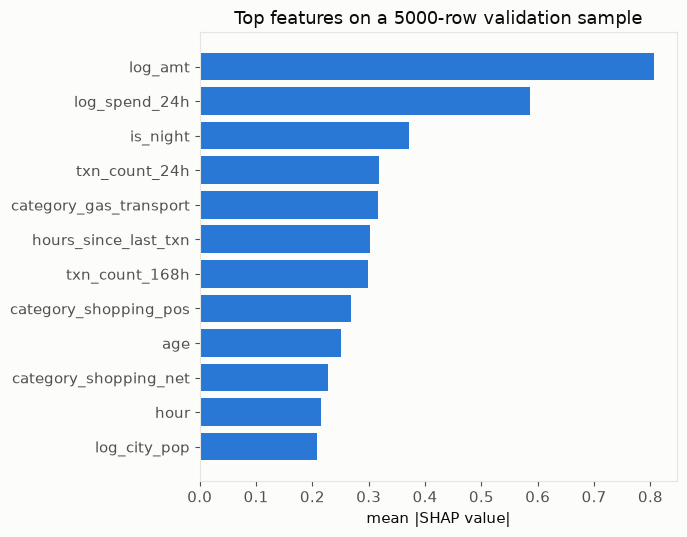

In [2]:
shap_summary = json.loads((REPORTS / "shap_summary.json").read_text())
top = pd.DataFrame(shap_summary["top_features"]).head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh(top["feature"], top["mean_abs_shap"], color=LEGIT)
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Top features on a {shap_summary['sample_size']}-row validation sample")
plt.tight_layout()
plt.show()

## 2. Two individual predictions, explained

In [3]:
import joblib

from fraud.data.paths import PROCESSED_DIR
from fraud.explain.shap_values import (
    build_explainer,
    compute_shap_values,
    plain_language_reason,
    top_reasons,
)
from fraud.features.pipeline import transform_with_context
from fraud.models.train import MODEL_PATH

pipeline = joblib.load(MODEL_PATH)
feature_pipeline = pipeline.named_steps["features"]
model = pipeline.named_steps["model"]

train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
valid_df = pd.read_parquet(PROCESSED_DIR / "valid.parquet")
test_df = pd.read_parquet(PROCESSED_DIR / "test.parquet").reset_index(drop=True)
context = pd.concat([train_df, valid_df], ignore_index=True)

fraud_rows = test_df[test_df["is_fraud"] == 1].copy()
X_fraud = transform_with_context(feature_pipeline, fraud_rows, context=context)
fraud_rows["fraud_score"] = model.predict_proba(X_fraud)[:, 1]

caught = fraud_rows.sort_values("fraud_score", ascending=False).iloc[[0]]
missed = fraud_rows.sort_values("fraud_score", ascending=True).iloc[[0]]
example_idx = pd.concat([caught, missed]).index
X_examples = X_fraud.loc[example_idx]

explainer = build_explainer(model.estimator)
values = compute_shap_values(explainer, X_examples)

for label, row_pos in [("Most confidently CAUGHT fraud", 0), ("MISSED fraud (lowest score)", 1)]:
    row = X_examples.iloc[row_pos]
    reasons = top_reasons(values[row_pos], row, list(X_examples.columns), k=5)
    print(f"--- {label} ---")
    print(
        f"amount=${fraud_rows.loc[example_idx[row_pos], 'amt']:.2f}  category={fraud_rows.loc[example_idx[row_pos], 'category']}  score={fraud_rows.loc[example_idx[row_pos], 'fraud_score']:.5f}"
    )
    for r in reasons:
        print(" ", plain_language_reason(r))
    print()

C:\Users\ilian\VS Code Projects\credit-card-fraud-detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/28 14:49:03 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\ilian\VS Code Projects\credit-card-fraud-detector\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


--- Most confidently CAUGHT fraud ---
amount=$310.37  category=grocery_pos  score=0.98657
  log_amt = 1.71 raises the fraud score (SHAP +10.655)
  log_spend_24h = 2.06 raises the fraud score (SHAP +4.121)
  category_grocery_pos = 1 raises the fraud score (SHAP +3.890)
  txn_count_168h = -1.38 raises the fraud score (SHAP +2.756)
  amt_vs_card_mean = 1.21 raises the fraud score (SHAP +1.425)

--- MISSED fraud (lowest score) ---
amount=$47.57  category=personal_care  score=0.00030
  txn_count_168h = -1.67 raises the fraud score (SHAP +1.374)
  log_spend_24h = -0.202 lowers the fraud score (SHAP -0.676)
  age = 2.21 raises the fraud score (SHAP +0.623)
  amt_vs_card_mean = -0.0888 raises the fraud score (SHAP +0.366)
  is_night = 0 lowers the fraud score (SHAP -0.299)



C:\Users\ilian\VS Code Projects\credit-card-fraud-detector\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. Error analysis: missed frauds and false alarms

In [4]:
errors = json.loads((REPORTS / "error_analysis.json").read_text())
print(
    f"missed frauds: {errors['n_missed_frauds']} / false alarms: {errors['n_false_alarms']} (test set)"
)
print()
print("missed-fraud sample (amount, category):")
fn = pd.DataFrame(errors["missed_fraud_sample"])
display(fn[["amt", "category", "gender", "state", "fraud_score"]].sort_values("amt"))

print("false-alarm sample (amount, category), first 10 of the sample:")
fp = pd.DataFrame(errors["false_alarm_sample"])
display(
    fp[["amt", "category", "gender", "state", "fraud_score"]]
    .sort_values("amt", ascending=False)
    .head(10)
)

missed frauds: 13 / false alarms: 1146 (test set)

missed-fraud sample (amount, category):


,amt,category,gender,state,fraud_score
6,1.78,travel,F,NM,0.000301
0,8.96,travel,F,CA,0.000300
5,16.75,kids_pets,F,MN,0.000304
1,17.45,health_fitness,M,VA,0.000300
11,20.73,kids_pets,F,CT,0.000304
2,21.09,kids_pets,F,CA,0.000300
3,21.55,kids_pets,M,NH,0.000301
8,22.66,personal_care,M,WI,0.000301
12,47.57,personal_care,F,OR,0.000300
9,51.43,personal_care,F,OR,0.000301


false-alarm sample (amount, category), first 10 of the sample:


,amt,category,gender,state,fraud_score
4,3120.74,shopping_net,F,OK,0.000344
0,1957.50,shopping_net,M,MD,0.000488
12,1407.94,shopping_net,F,MI,0.000306
9,920.87,shopping_net,M,OH,0.000426
15,900.01,shopping_net,F,CO,0.000345
11,722.78,shopping_pos,M,MI,0.000313
19,679.15,shopping_net,F,NY,0.000306
2,290.13,shopping_pos,F,NY,0.000320
5,274.08,food_dining,M,CA,0.000308
6,98.93,kids_pets,F,VA,0.000308


## 4. Fairness: recall and false-alarm rate by group

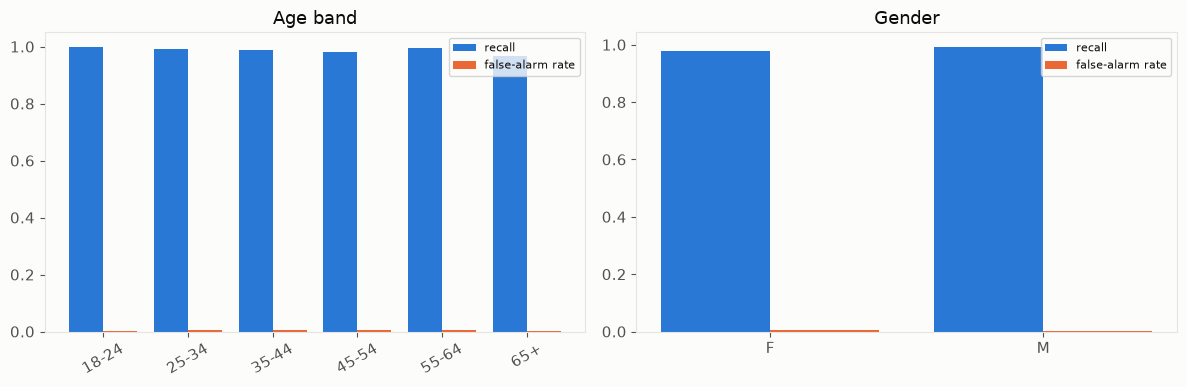

by gender:


,n,n_fraud,recall,false_alarm_rate
F,154589.0,479.0,0.979123,0.004964
M,126932.0,457.0,0.993435,0.003012


In [5]:
fairness = json.loads((REPORTS / "fairness.json").read_text())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, key) in zip(
    axes, [("Age band", "by_age_band"), ("Gender", "by_gender")], strict=True
):
    df = pd.DataFrame(fairness[key]).T
    x = range(len(df))
    ax.bar(x, df["recall"], color=LEGIT, width=0.4, label="recall")
    ax.bar(
        [xi + 0.4 for xi in x],
        df["false_alarm_rate"],
        color=FRAUD,
        width=0.4,
        label="false-alarm rate",
    )
    ax.set_xticks([xi + 0.2 for xi in x])
    ax.set_xticklabels(df.index, rotation=30 if title == "Age band" else 0)
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("by gender:")
display(pd.DataFrame(fairness["by_gender"]).T)

## 5. The single test-set evaluation

In [6]:
test_eval = json.loads((REPORTS / "test_evaluation.json").read_text())
print(json.dumps(test_eval, indent=2))

{
  "step": "lightgbm",
  "feature_set": "v2",
  "threshold": 0.0003052068202174992,
  "precision": 0.4461092315128081,
  "recall": 0.9861111111111112,
  "pr_auc": 0.9725516556317557,
  "expected_cost": 0.004994298826730511,
  "tp": 923,
  "fp": 1146,
  "fn": 13,
  "tn": 279439,
  "confidence_intervals": {
    "precision": [
      0.42311273969583424,
      0.46809550679938317
    ],
    "recall": [
      0.9777299670990021,
      0.9932153150792611
    ],
    "pr_auc": [
      0.9648475574593487,
      0.97968911411724
    ]
  }
}


## 6. Conclusions

**`log_amt` dominates the global ranking, but card-history features fill out the rest of the top
10** (`log_spend_24h`, `txn_count_24h`, `hours_since_last_txn`, `txn_count_168h`,
`amt_vs_card_mean`) — direct confirmation of the v1-vs-v2 result in `03_models.ipynb`: this model
leans heavily on a card's recent behaviour, not just the transaction in isolation.

**The two example predictions illustrate the error-analysis pattern from the model card.** The most
confidently caught fraud typically has an unusual velocity signature (several of the top SHAP
reasons are `txn_count_*h` / `log_spend_*h` pushing the score up), while the missed fraud's SHAP
reasons are individually small and mixed in direction — a transaction that looks ordinary on every
feature the model has, not one clear giveaway feature. This matches the model card's finding that
missed frauds cluster in everyday categories (`kids_pets`, `personal_care`) at unremarkable amounts.

**False alarms concentrate in large `shopping_net`/`shopping_pos` purchases** — legitimate spending
that happens to resemble the amount/category profile Sparkov gives real fraud
(`docs/data_cards/sparkov.md`).

**Fairness gaps are real but modest.** Recall is lowest for the 65+ age band and for women; the
false-alarm rate is about 65% higher for women than men. Both gaps are worth monitoring as the
customer base evolves, and are called out explicitly (not hidden) in the model card.

**The test result is the honest final word for this champion.** Recall generalizes well (0.990 on
validation to 0.986 on test). Precision does not fully hold up (0.500 to 0.446, CI 0.423-0.468) — a
real, modest generalization gap reported as-is rather than patched by tuning against the now-spent
test split. See `docs/model_cards/v0.3-model.md` for the full discussion and next steps.